# Week 9: Uncertainty and Calibration for UHPC Predictions

**Target:** UHPC 28-day compressive strength (`cs_28d`)  
**Dataset:** corrected shared semantic-recoded 50 percent dataset  
**Goal:** evaluate whether prediction intervals are calibrated for unseen publications.

Week 9 builds on the refreshed Week 8 publication split and frozen Linear Family model settings. The point model is not retuned here; the focus is uncertainty.

## Executive Summary

- Week 9 reuses the **2073-row** shared Week 8 modeling table and publication split.
- The Elastic Net split-conformal interval has **89.4%** shared-test coverage with mean width **94.461 MPa**.
- Native Bayesian Ridge under-covers at **83.0%** shared-test coverage.
- Raw Elastic Net residual-bootstrap intervals under-cover at **74.3%** shared-test coverage.
- Conformalized bootstrap has **91.6%** shared-test coverage and the best shared-test Winkler score, but it is more complex than ordinary split conformal.
- In thresholded LOPO, split conformal reaches **93.8% micro coverage** and **93.4% macro coverage** over six reliable publications.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
from IPython.display import Image, display

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 180)

cwd = Path.cwd().resolve()
if (cwd / 'configs' / 'week09_uncertainty_calibration.yaml').exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / 'configs' / 'week09_uncertainty_calibration.yaml').exists():
    PROJECT_ROOT = cwd.parent
else:
    raise FileNotFoundError('Open this notebook from S1_Linear or S1_Linear/notebooks.')

TABLES = PROJECT_ROOT / 'reports' / 'tables' / 'week09'
FIGURES = PROJECT_ROOT / 'reports' / 'figures' / 'week09'
METRICS = PROJECT_ROOT / 'results' / 'metrics' / 'week09'
PREDICTIONS = PROJECT_ROOT / 'results' / 'predictions' / 'week09'


def show_figure(name, width=1050):
    path = FIGURES / name
    if path.exists():
        display(Image(filename=str(path), width=width))
    else:
        print(f'Missing figure: {path}')

readiness = pd.read_csv(TABLES / 'week09_input_readiness_audit.csv')
shared_metrics = pd.read_csv(METRICS / 'week09_shared_interval_metrics.csv')
shared_publications = pd.read_csv(TABLES / 'week09_shared_publication_interval_metrics.csv')
shared_predictions = pd.read_csv(PREDICTIONS / 'week09_shared_interval_predictions.csv')
shared_curve = pd.read_csv(TABLES / 'week09_shared_coverage_curve.csv')
shared_quantiles = pd.read_csv(TABLES / 'week09_shared_calibration_quantiles.csv')
shared_confidence = pd.read_csv(TABLES / 'week09_shared_confidence_diagnostics.csv')
shared_overconfident = pd.read_csv(TABLES / 'week09_shared_overconfident_rows.csv')
shared_roles = pd.read_csv(TABLES / 'week09_shared_role_summary.csv')
shared_leakage = pd.read_csv(TABLES / 'week09_shared_leakage_audit.csv')
lopo_summary = pd.read_csv(TABLES / 'week09_lopo_micro_macro_summary.csv')
lopo_publications = pd.read_csv(METRICS / 'week09_lopo_publication_interval_metrics.csv')
lopo_predictions = pd.read_csv(PREDICTIONS / 'week09_lopo_interval_predictions.csv')
lopo_roles = pd.read_csv(TABLES / 'week09_lopo_role_summary.csv')
lopo_leakage = pd.read_csv(TABLES / 'week09_lopo_leakage_audit.csv')
lopo_comparison = pd.read_csv(TABLES / 'week09_lopo_week08_error_calibration_comparison.csv')

print('Week 9 artifacts loaded from:', PROJECT_ROOT)

Week 9 artifacts loaded from: /Users/apple/Brijesh/DE/SoSe2026/Special Project/Data-to-Design-ML/S1_Linear


## 1. What Was Reused From Week 8

Week 9 reuses:

- shared Week 8 train/validation/test publication splits;
- the 33 raw predictor schema and 60-column preprocessing contract inside the model pipelines;
- frozen selected model settings from Week 8;
- the 50-row reliable-publication threshold for LOPO.

The saved Week 8 selected model is not directly reused for conformal calibration because it was fitted on train plus validation. Week 9 refits frozen pipelines on training publications only, leaving validation publications for calibration.

In [2]:
display(readiness[['check', 'value', 'status', 'detail']])
assert set(readiness['status']) == {'pass'}

,check,value,status,detail
0,week08_config_exists,True,pass,/Users/apple/Brijesh/DE/SoSe2026/Special Proje...
1,week08_split_dir_exists,True,pass,/Users/apple/Brijesh/DE/SoSe2026/Special Proje...
2,week08_modeling_data_exists,True,pass,/Users/apple/Brijesh/DE/SoSe2026/Special Proje...
3,week08_modeling_lineage_exists,True,pass,/Users/apple/Brijesh/DE/SoSe2026/Special Proje...
4,week08_split_manifest_exists,True,pass,/Users/apple/Brijesh/DE/SoSe2026/Special Proje...
5,week08_frozen_config_exists,True,pass,/Users/apple/Brijesh/DE/SoSe2026/Special Proje...
6,week08_lopo_metrics_exists,True,pass,/Users/apple/Brijesh/DE/SoSe2026/Special Proje...
7,train_row_alignment,1451/1451/1451,pass,X/y/lineage row counts
8,calibration_row_alignment,311/311/311,pass,X/y/lineage row counts
9,test_row_alignment,311/311/311,pass,X/y/lineage row counts


## 2. Leakage Controls

The shared evaluation has three disjoint publication roles:

- training publications fit preprocessing and point models;
- calibration publications estimate interval size or conformal correction;
- test publications evaluate interval coverage and width once.

Publication metadata is attached only for diagnostics and never enters the predictor matrix.

In [3]:
display(shared_roles)
display(shared_leakage)
assert set(shared_leakage['status']) == {'pass'}

,evaluation_fold,role,n_rows,n_publications
0,shared_publication_test,train,1451,115
1,shared_publication_test,calibration,311,25
2,shared_publication_test,heldout,311,25


,evaluation_fold,check,value,status
0,shared_publication_test,train_calibration_publication_overlap,0,pass
1,shared_publication_test,train_heldout_publication_overlap,0,pass
2,shared_publication_test,calibration_heldout_publication_overlap,0,pass
3,shared_publication_test,all_rows_assigned,2073,pass
4,shared_publication_test,assignment_uses_target_values,False,pass


## 3. Interval Methods

For the primary 90% interval:

- Elastic Net split conformal uses the finite-sample absolute-residual quantile. The 90% `q_hat` is **47.231 MPa**, so the interval width is about **94.461 MPa**.
- Bayesian Ridge native uses Gaussian predictive standard deviations.
- Bayesian Ridge conformalized calibrates residuals divided by predictive standard deviation.
- Elastic Net residual bootstrap estimates empirical prediction distributions.
- Bootstrap conformalized expands raw bootstrap bounds using validation misses.

In [4]:
display(shared_quantiles.loc[np.isclose(shared_quantiles['nominal_coverage'], 0.90), [
    'method', 'calibration_score_type', 'n_calibration_rows',
    'finite_sample_rank', 'quantile_level', 'q_hat', 'bootstrap_repetitions'
]].round(4))

,method,calibration_score_type,n_calibration_rows,finite_sample_rank,quantile_level,q_hat,bootstrap_repetitions
2,elastic_net_split_conformal,absolute_validation_residual,311,281.0,0.9035,47.2307,NaN
6,bayesian_ridge_native,gaussian_predictive_z,311,NaN,NaN,1.6449,NaN
10,bayesian_ridge_conformalized,absolute_residual_over_predictive_std,311,281.0,0.9035,2.0876,NaN
16,elastic_net_residual_bootstrap,bootstrap_percentile_bounds,311,NaN,NaN,NaN,300.0
17,elastic_net_bootstrap_conformalized,outside_bootstrap_interval_distance,311,281.0,0.9035,14.1025,NaN


## 4. Shared Publication-Held-Out Results

The main comparison uses the same training, calibration, and held-out publication roles for every method.

,method,EmpiricalCoverage,CoverageGap,MeanIntervalWidth,MeanWinklerScore,MAE,RMSE,R2,Bias,UncertaintyErrorSpearman
4,elastic_net_bootstrap_conformalized,0.916,0.016,95.148,110.597,23.423,28.488,0.493,8.019,0.020
0,elastic_net_split_conformal,0.894,-0.006,94.461,111.603,23.423,28.488,0.493,8.019,NaN
2,bayesian_ridge_conformalized,0.936,0.036,108.020,121.015,22.637,27.719,0.520,6.569,0.063
1,bayesian_ridge_native,0.830,-0.070,85.111,121.322,22.637,27.719,0.520,6.569,0.063
3,elastic_net_residual_bootstrap,0.743,-0.157,66.943,128.903,23.423,28.488,0.493,8.019,0.020


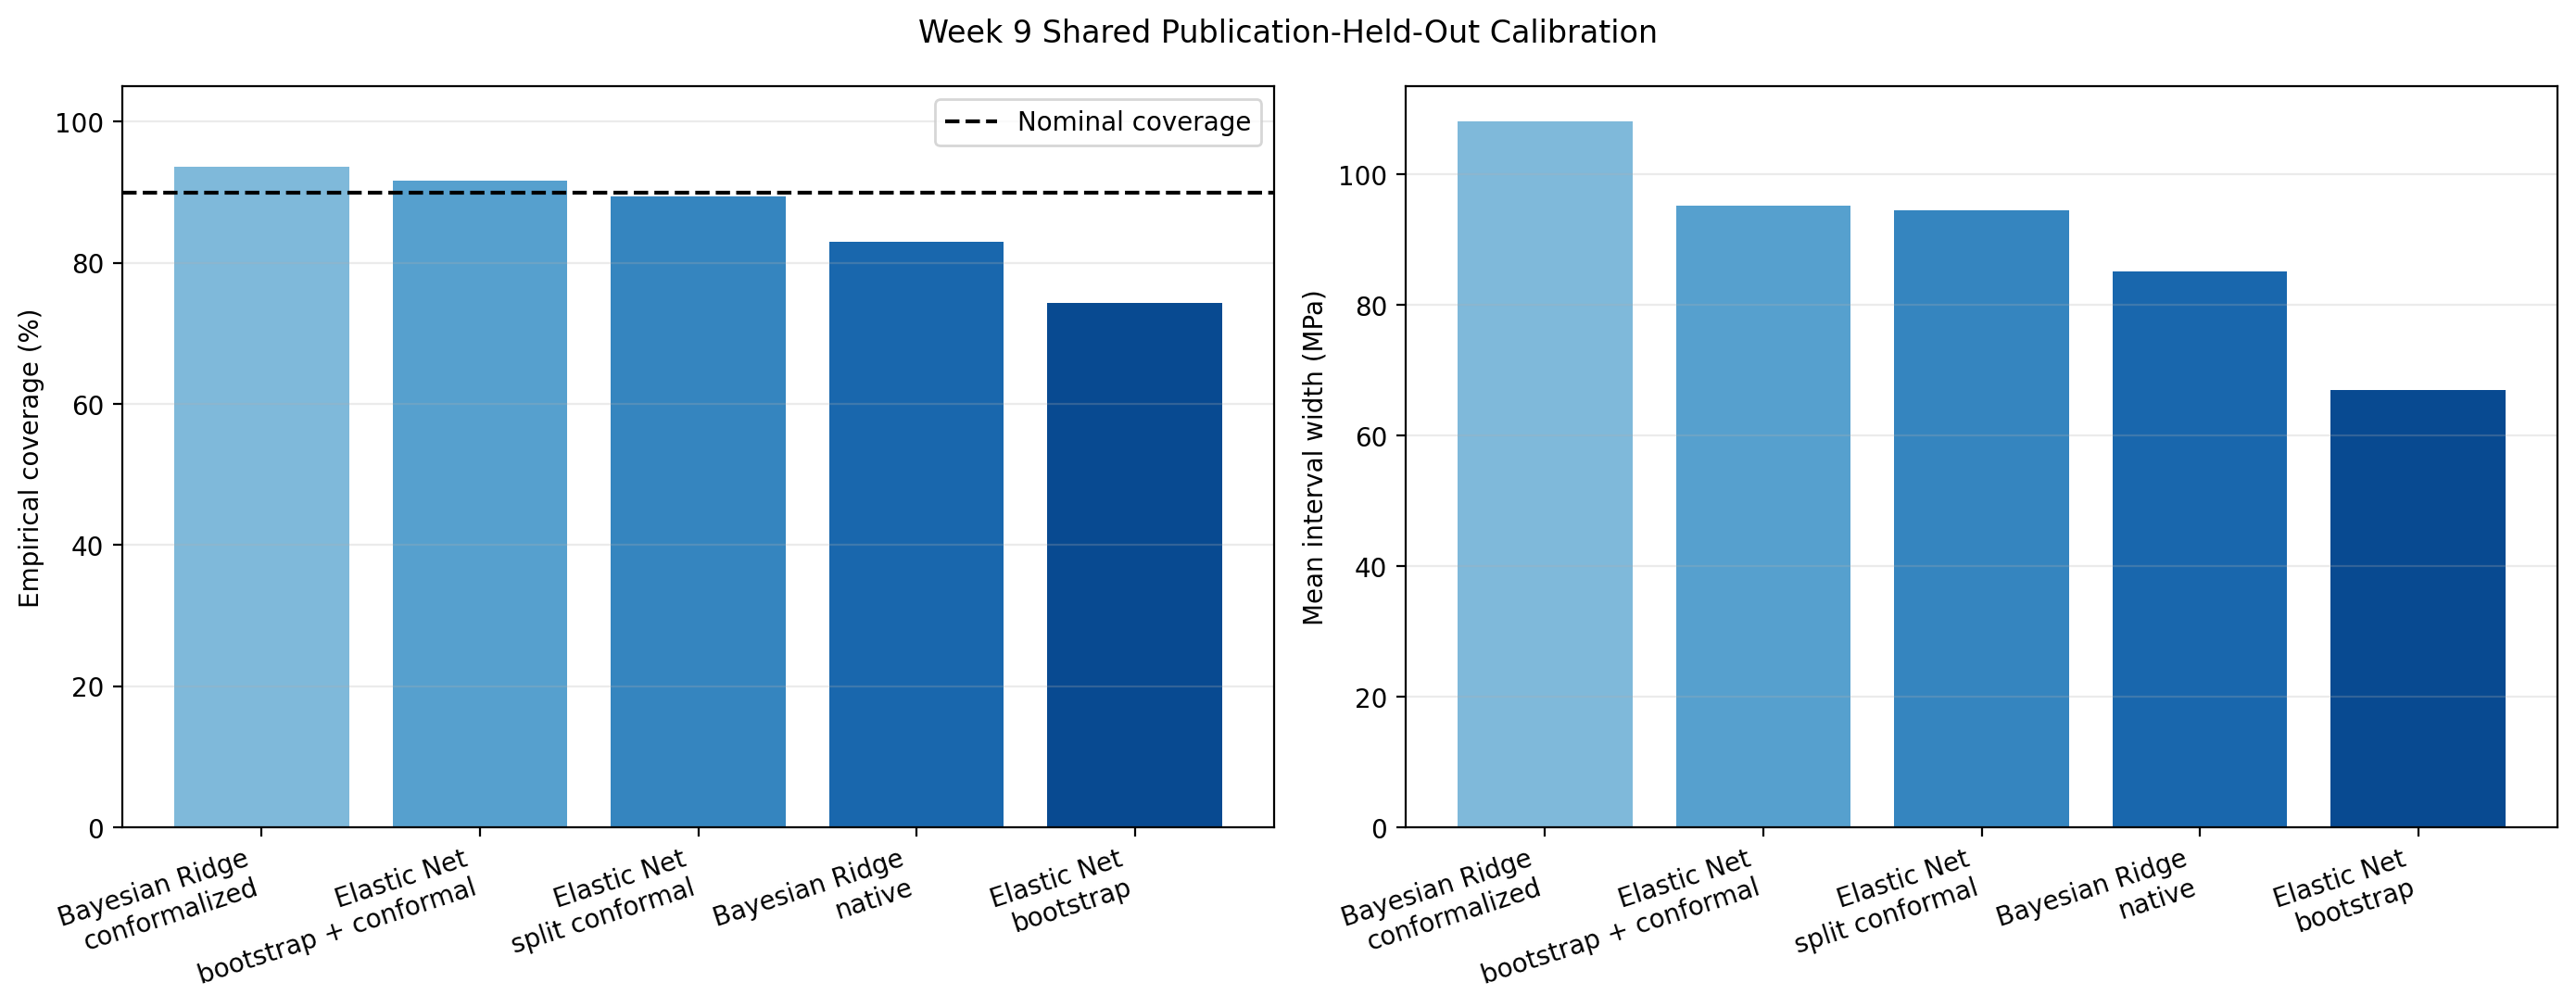

In [5]:
columns = [
    'method', 'EmpiricalCoverage', 'CoverageGap', 'MeanIntervalWidth',
    'MeanWinklerScore', 'MAE', 'RMSE', 'R2', 'Bias',
    'UncertaintyErrorSpearman'
]
display(shared_metrics[columns].sort_values('MeanWinklerScore').round(3))
show_figure('week09_method_coverage_width.png', width=1150)

### Shared-Test Interpretation

Raw model-based intervals are too optimistic: native Bayesian Ridge and raw residual bootstrap both under-cover. Conformal correction is doing the important reliability work.

Split conformal is simple and close to the 90% target, but bootstrap conformalization gives a slightly better shared-test Winkler score in this refreshed run. The practical interpretation is not that one method is universally superior; it is that **uncalibrated uncertainty is unsafe**, while conformal calibration makes intervals much more reliable.

## 5. Coverage Across Nominal Levels

Evaluating only 90% can hide behavior at other coverage levels, so the runner also saves 50%, 80%, 90%, and 95% interval summaries.

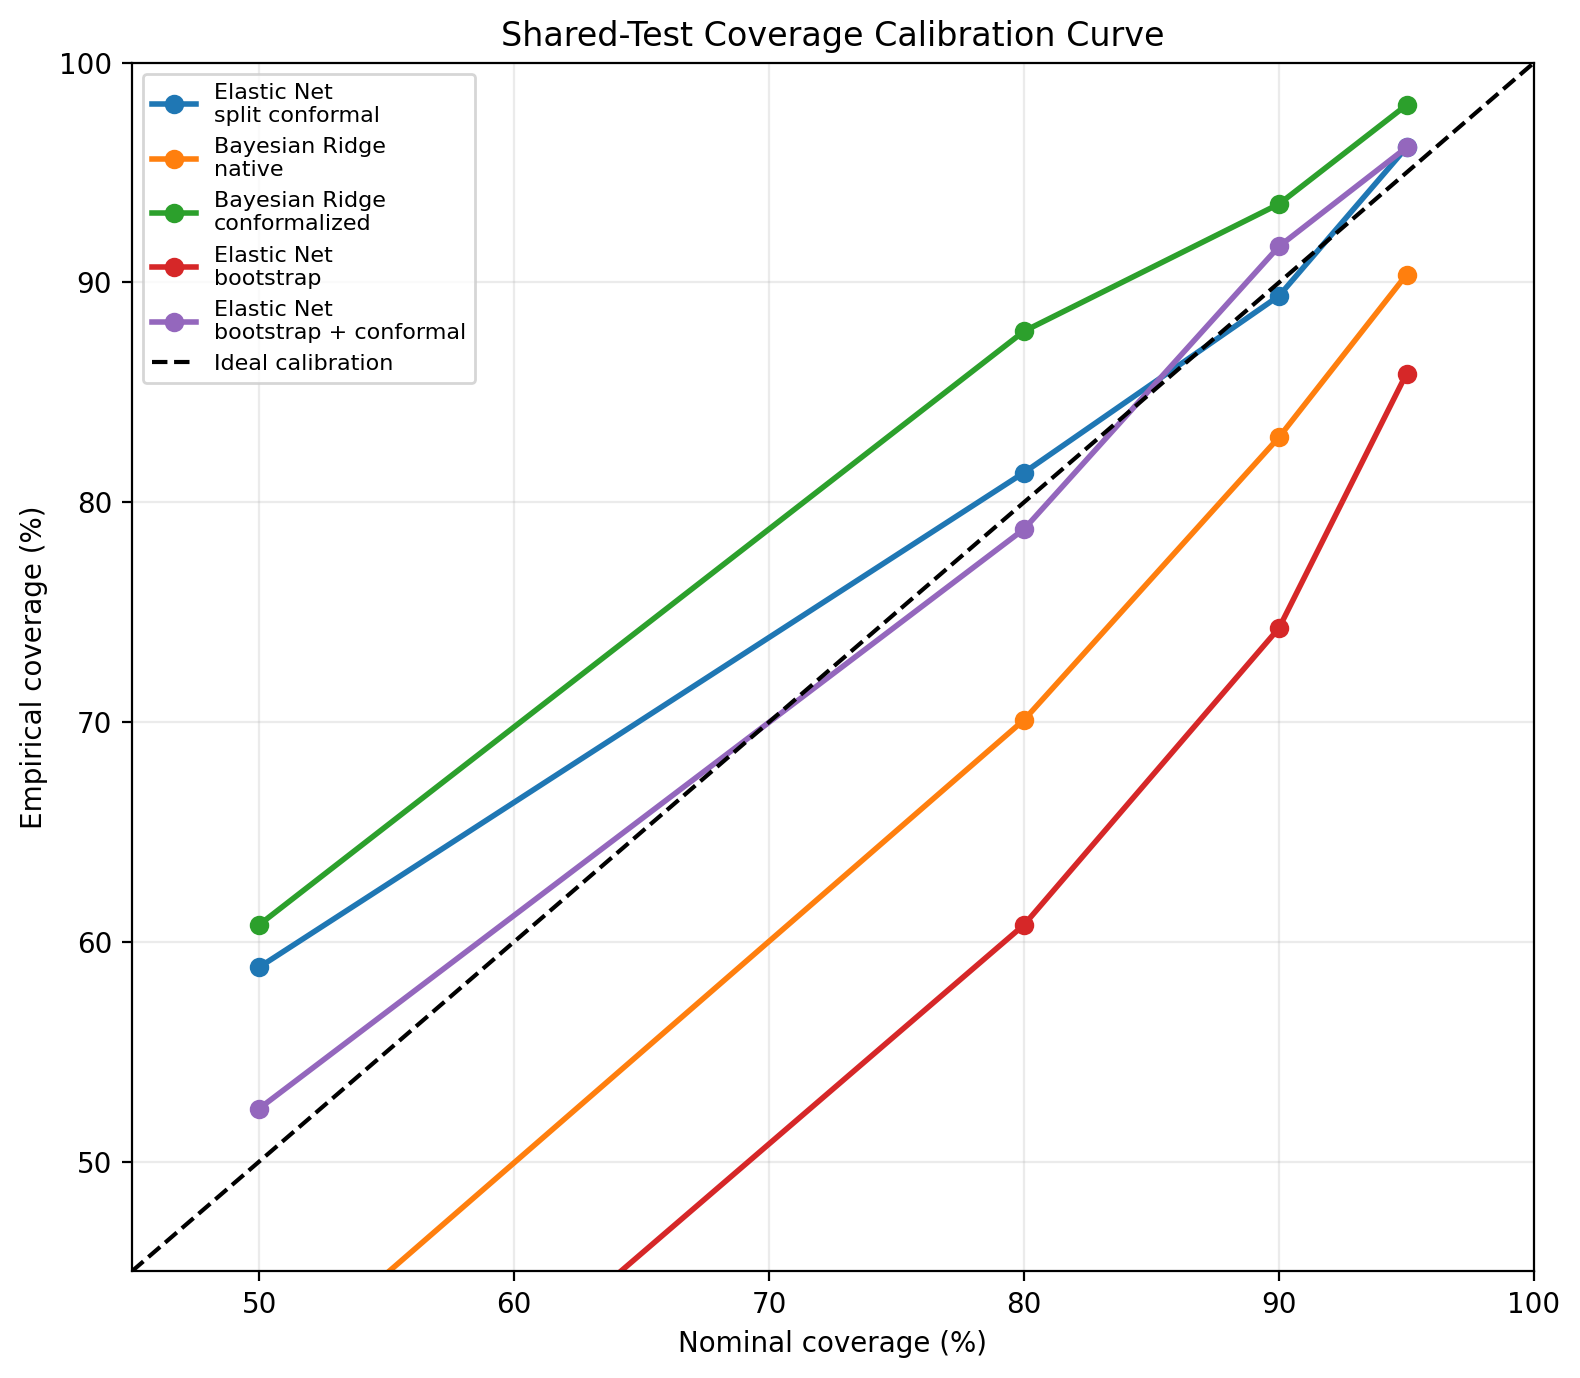

,method,nominal_coverage,EmpiricalCoverage,MeanIntervalWidth
0,elastic_net_split_conformal,0.50,0.588,48.743
1,elastic_net_split_conformal,0.80,0.814,77.734
2,elastic_net_split_conformal,0.90,0.894,94.461
3,elastic_net_split_conformal,0.95,0.961,119.071
4,bayesian_ridge_native,0.50,0.399,34.901
5,bayesian_ridge_native,0.80,0.701,66.312
6,bayesian_ridge_native,0.90,0.830,85.111
7,bayesian_ridge_native,0.95,0.904,101.416
8,bayesian_ridge_conformalized,0.50,0.608,53.867
9,bayesian_ridge_conformalized,0.80,0.878,91.467


In [6]:
show_figure('week09_coverage_curve.png', width=850)
display(shared_curve[['method', 'nominal_coverage', 'EmpiricalCoverage', 'MeanIntervalWidth']].round(3))

## 6. Publication-Level Coverage and Overconfident Rows

Overall coverage can hide publications where all rows are missed. Publication-level diagnostics and overconfident-row tables identify where intervals are too narrow.

,publication_group,n_rows,CoverageEvidence,EmpiricalCoverage,MeanIntervalWidth,RMSE,Bias,ConfidenceDiagnostic
8,Ref-109-Research,2,limited_n_lt_10,0.000,94.461,79.017,78.980,narrow_but_wrong
9,Ref-111-Research,2,limited_n_lt_10,0.000,94.461,57.291,56.964,narrow_but_wrong
19,Ref-55-Research,5,limited_n_lt_10,0.600,94.461,41.528,-40.871,narrow_but_wrong
24,Ref-108-Research,3,limited_n_lt_10,0.667,94.461,47.874,-45.905,narrow_but_wrong
32,Ref-48-Research,72,more_stable_n_ge_10,0.792,94.461,33.507,18.297,narrow_but_wrong
35,Ref-161-Research,6,limited_n_lt_10,0.833,94.461,41.747,-40.324,narrow_but_wrong
95,Ref-144-Research,112,more_stable_n_ge_10,0.929,94.461,25.367,12.212,well_calibrated_or_sharp
77,Ref-65-Research,30,more_stable_n_ge_10,0.933,94.461,28.865,16.333,well_calibrated_or_sharp
83,Ref-35-Research,1,limited_n_lt_10,1.000,94.461,5.161,-5.161,well_calibrated_or_sharp
91,Ref-97-Research,1,limited_n_lt_10,1.000,94.461,1.821,-1.821,well_calibrated_or_sharp


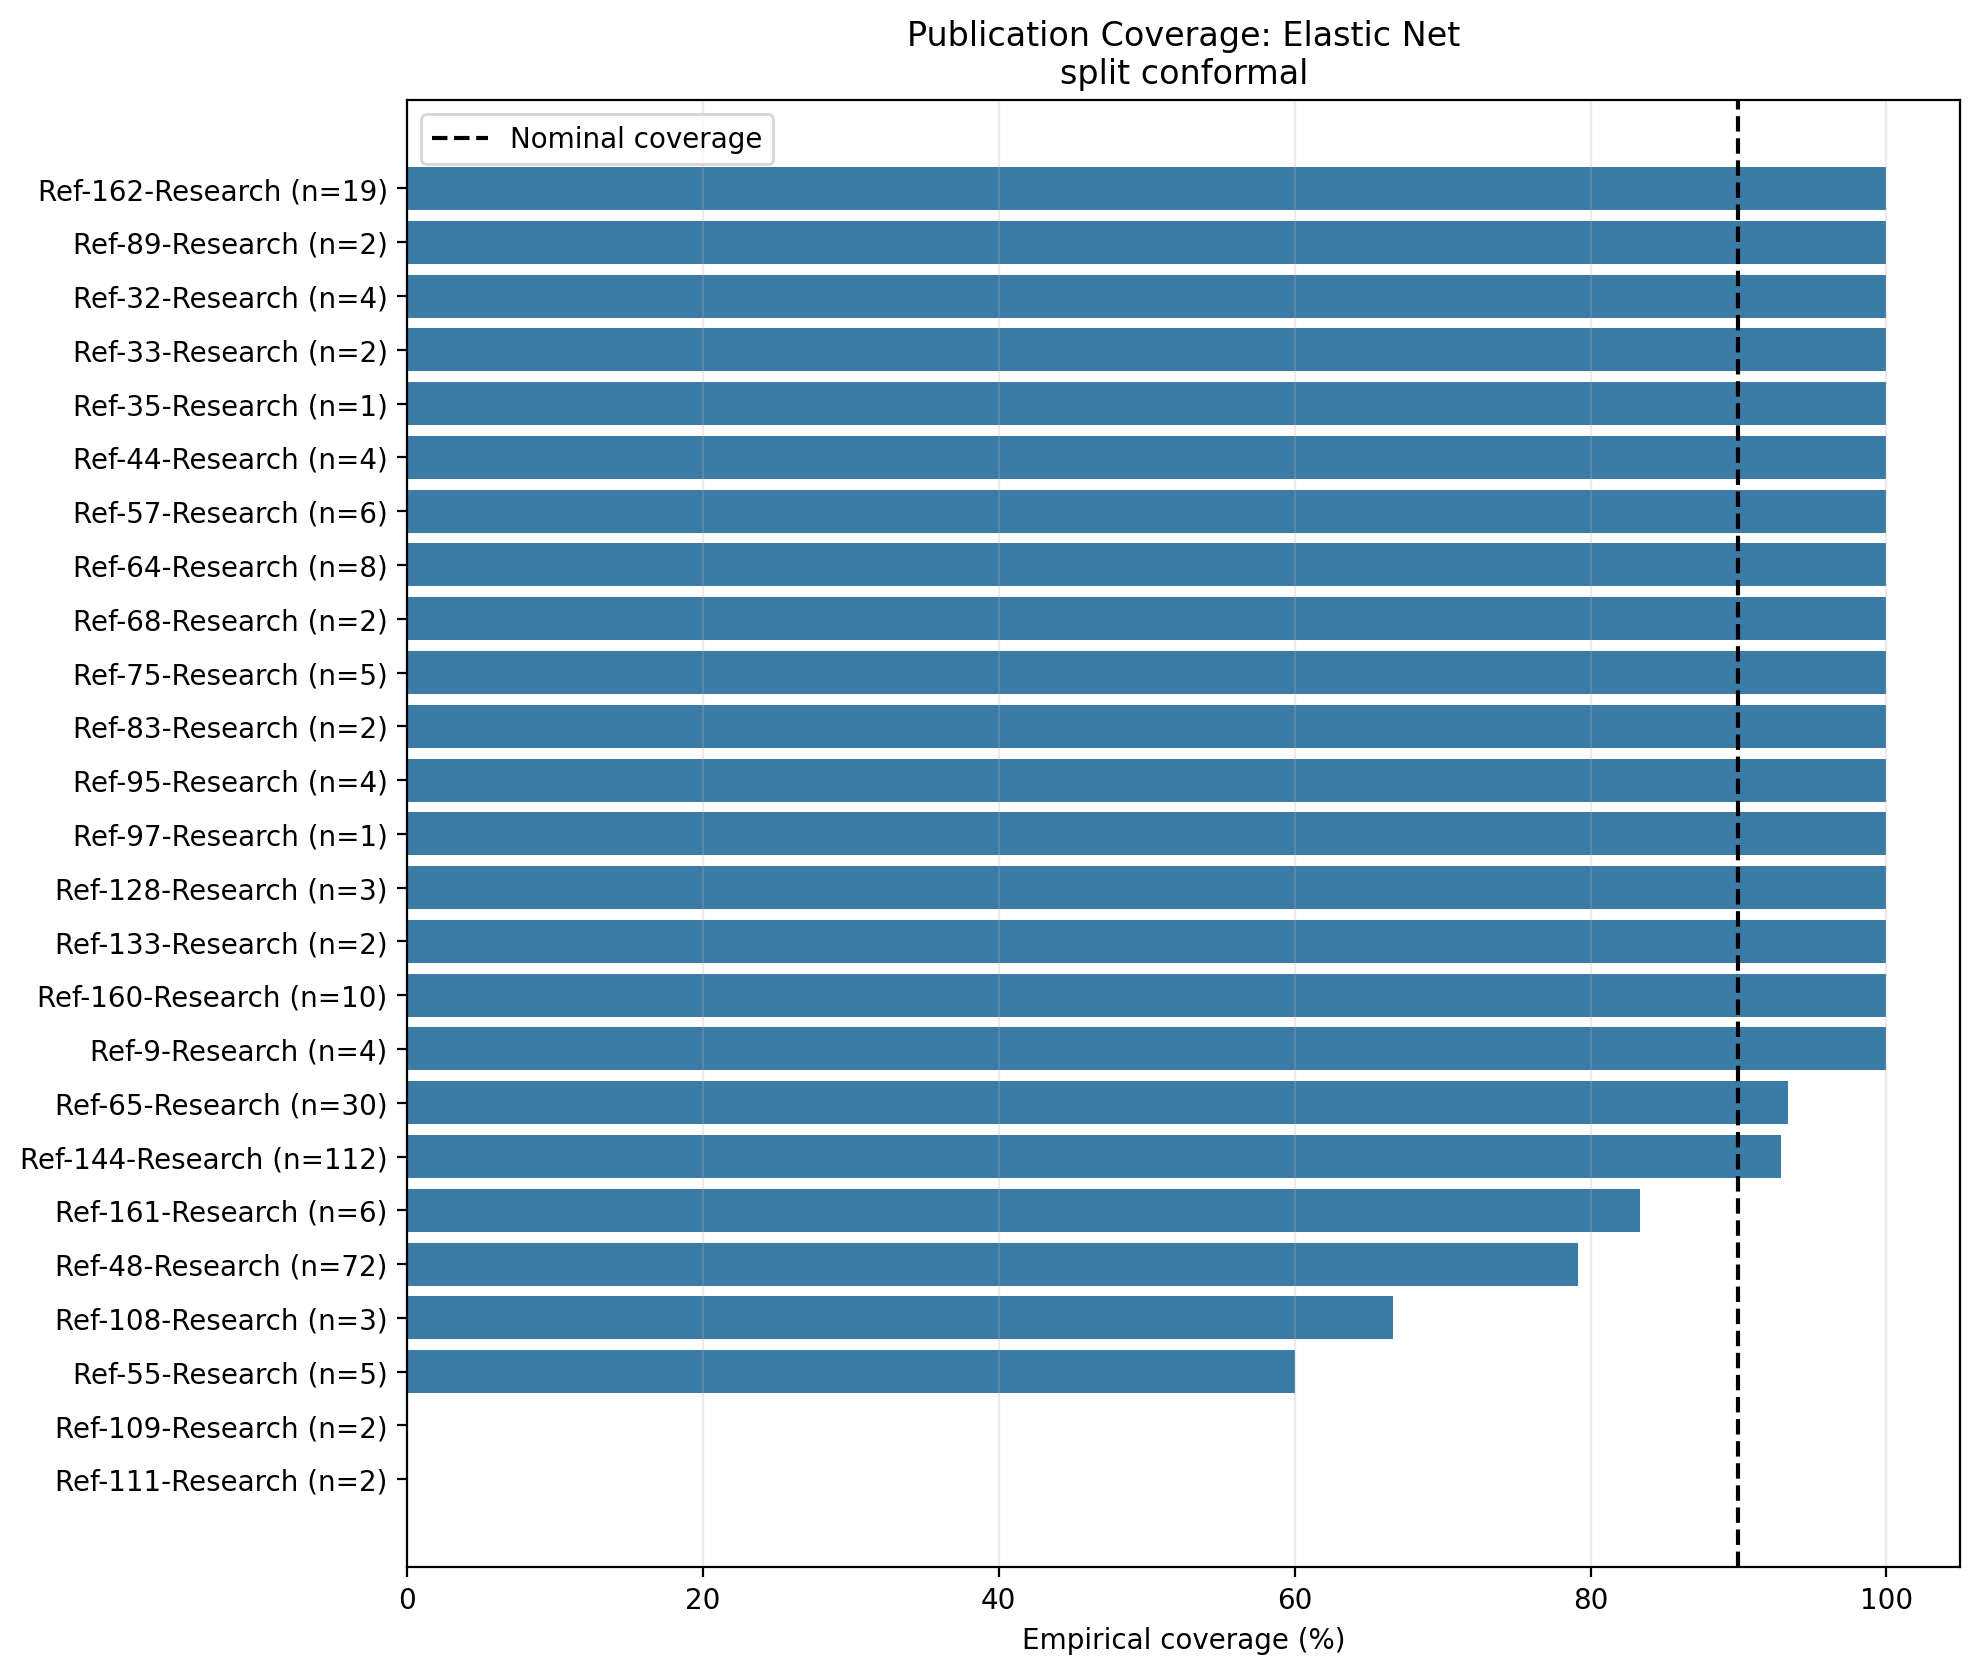

,method,publication_group,Actual,Predicted,Lower,Upper,AbsoluteError,IntervalWidth,StandardizedError,MissDirection
0,elastic_net_residual_bootstrap,Ref-109-Research,250.0,173.429,143.627,207.833,76.571,64.206,2.385,above_interval_underprediction
1,elastic_net_residual_bootstrap,Ref-109-Research,230.0,148.610,116.421,189.165,81.390,72.744,2.238,above_interval_underprediction
2,bayesian_ridge_native,Ref-109-Research,230.0,149.820,111.621,188.020,80.180,76.400,2.099,above_interval_underprediction
3,elastic_net_residual_bootstrap,Ref-144-Research,229.0,164.143,135.023,198.892,64.857,63.869,2.031,above_interval_underprediction
4,bayesian_ridge_native,Ref-109-Research,250.0,174.590,136.362,212.819,75.410,76.458,1.973,above_interval_underprediction
5,elastic_net_residual_bootstrap,Ref-108-Research,105.0,169.875,130.188,197.313,64.875,67.125,1.933,below_interval_overprediction
6,elastic_net_residual_bootstrap,Ref-144-Research,225.0,165.350,137.844,201.289,59.650,63.445,1.880,above_interval_underprediction
7,elastic_net_residual_bootstrap,Ref-161-Research,83.0,144.369,113.775,179.676,61.369,65.901,1.862,below_interval_overprediction
8,elastic_net_residual_bootstrap,Ref-144-Research,223.0,162.909,131.257,196.642,60.091,65.385,1.838,above_interval_underprediction
9,elastic_net_residual_bootstrap,Ref-111-Research,192.0,128.916,94.265,163.716,63.084,69.450,1.817,above_interval_underprediction


In [7]:
split_conformal_publications = shared_confidence.query(
    "method == 'elastic_net_split_conformal'"
).sort_values(['EmpiricalCoverage', 'n_rows'])
display(split_conformal_publications[[
    'publication_group', 'n_rows', 'CoverageEvidence', 'EmpiricalCoverage',
    'MeanIntervalWidth', 'RMSE', 'Bias', 'ConfidenceDiagnostic'
]].head(12).round(3))
show_figure('week09_publication_coverage.png', width=950)

display(shared_overconfident[[
    'method', 'publication_group', 'Actual', 'Predicted', 'Lower', 'Upper',
    'AbsoluteError', 'IntervalWidth', 'StandardizedError', 'MissDirection'
]].head(15).round(3))

## 7. Do Adaptive Widths Track Error?

Split conformal has constant width, so it cannot rank rows by uncertainty. Bayesian and bootstrap intervals have row-varying widths, but those widths are useful only if they correlate with actual error.

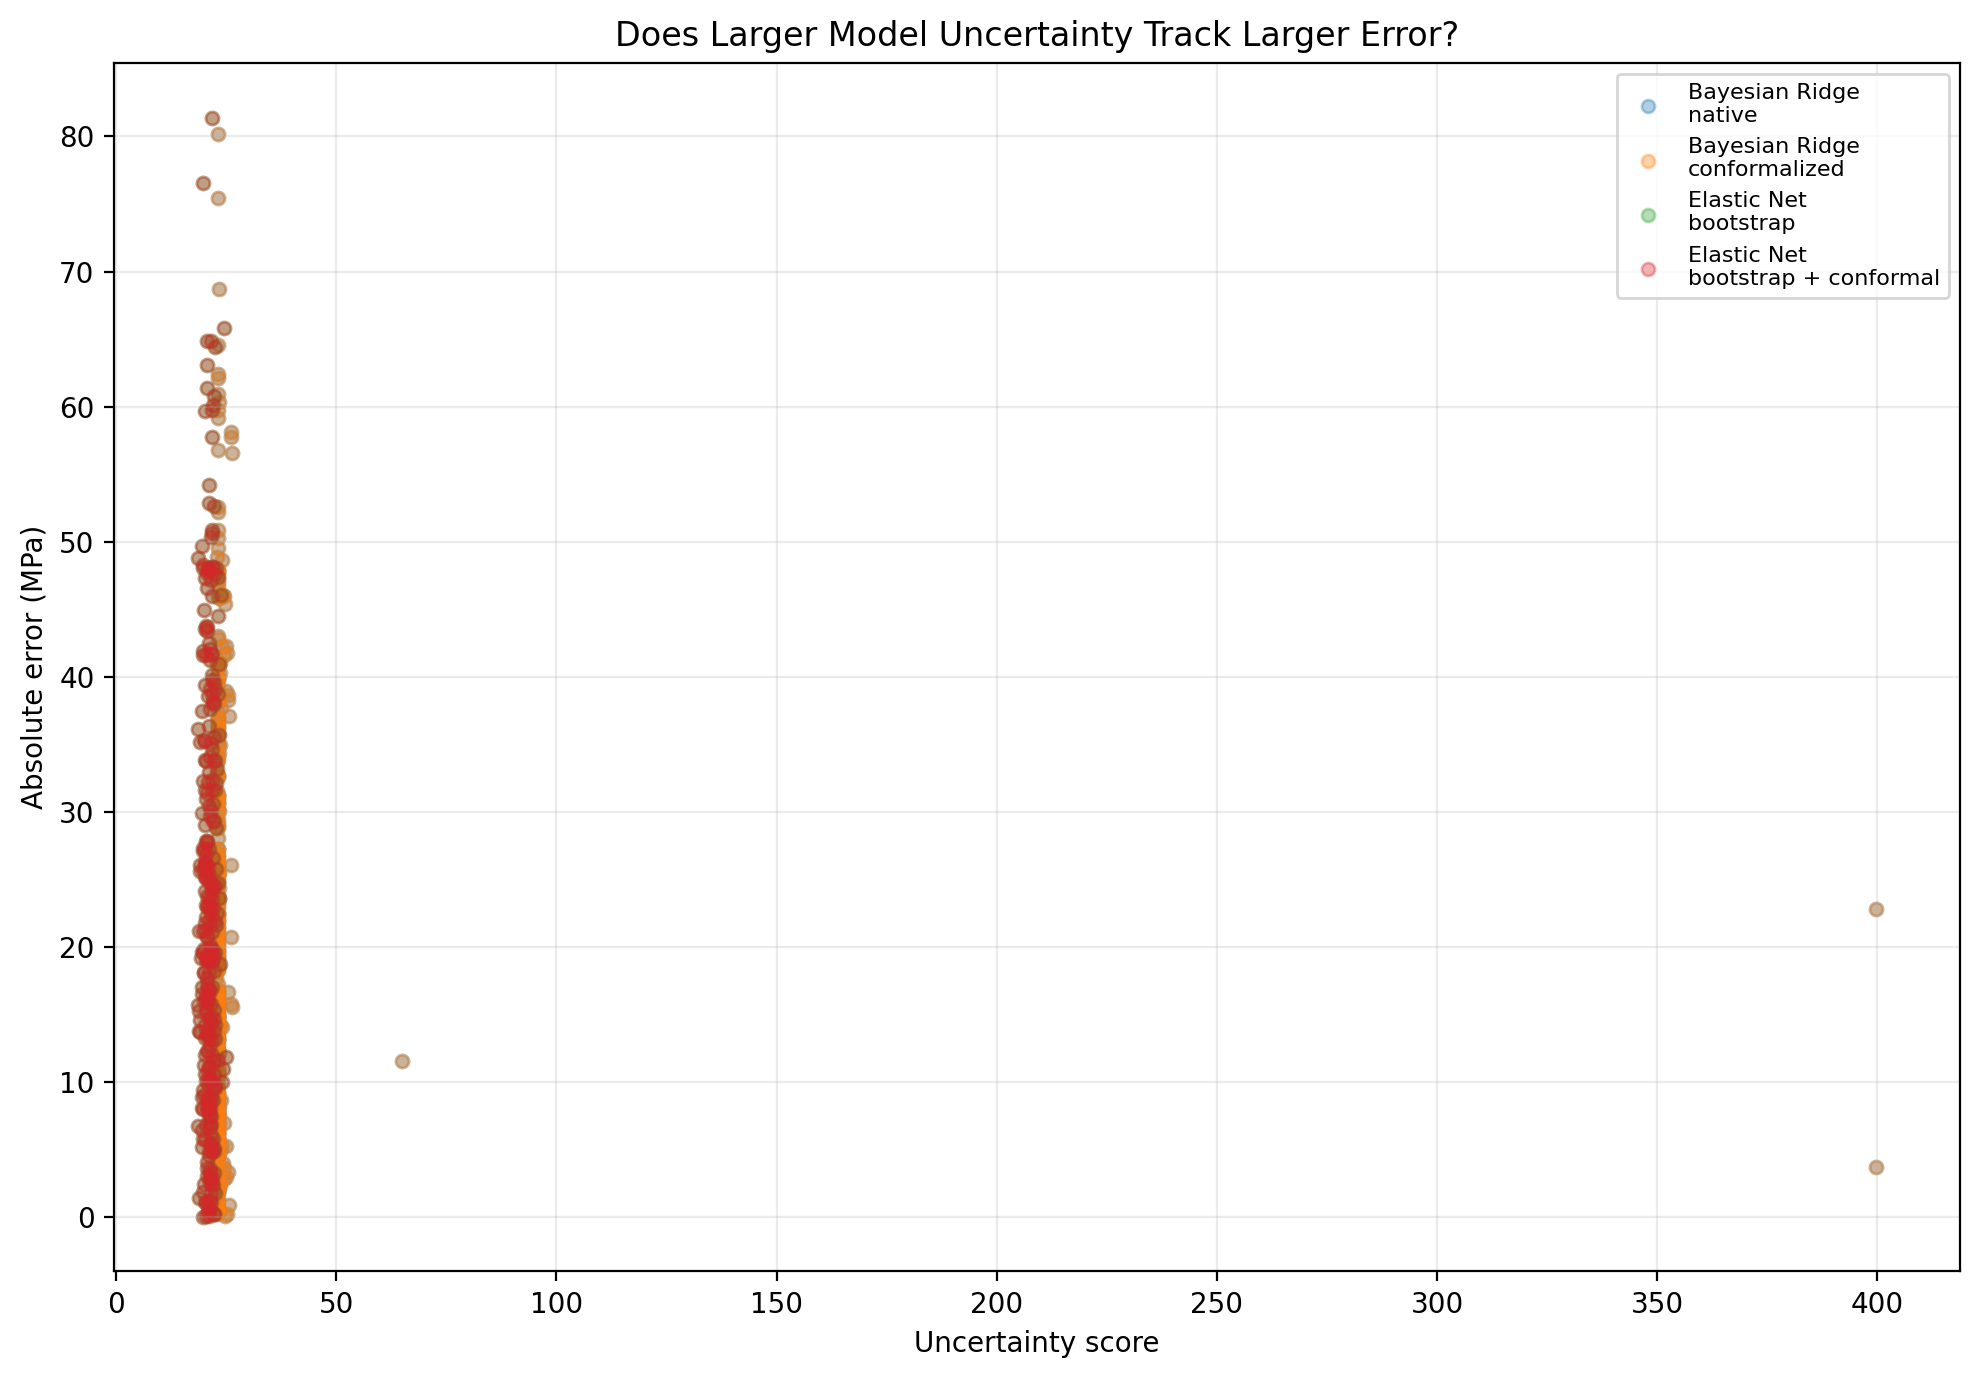

,method,UncertaintyErrorSpearman
0,elastic_net_split_conformal,NaN
1,bayesian_ridge_native,0.063
2,bayesian_ridge_conformalized,0.063
3,elastic_net_residual_bootstrap,0.020
4,elastic_net_bootstrap_conformalized,0.020


In [8]:
show_figure('week09_uncertainty_vs_error.png', width=950)
display(shared_metrics[['method', 'UncertaintyErrorSpearman']].round(3))

## 8. Thresholded LOPO Calibration

LOPO is rerun with calibration roles because Week 8 LOPO was only a point-prediction experiment. Only publications with at least 50 rows are evaluated for reliable publication-level metrics.

,evaluation_fold,role,n_rows,n_publications
0,Ref-144-Research,train,1650,139
1,Ref-144-Research,calibration,311,25
2,Ref-144-Research,heldout,112,1
3,Ref-121-Research,train,1762,140
4,Ref-121-Research,calibration,231,24
5,Ref-121-Research,heldout,80,1
6,Ref-141-Research,train,1762,140
7,Ref-141-Research,calibration,238,24
8,Ref-141-Research,heldout,73,1
9,Ref-48-Research,train,1690,139


,method,aggregation,n_publications,n_rows,EmpiricalCoverage,CoverageGap,MeanIntervalWidth,MeanWinklerScore,RMSE,R2
0,elastic_net_split_conformal,micro_all_rows,6,452,0.938,0.038,101.898,111.785,29.455,0.176
1,elastic_net_split_conformal,macro_equal_publication_weight,6,452,0.934,0.034,101.931,112.562,29.541,-1.350
2,bayesian_ridge_native,micro_all_rows,6,452,0.754,-0.146,77.801,122.807,30.312,0.128
3,bayesian_ridge_native,macro_equal_publication_weight,6,452,0.747,-0.153,77.864,125.107,30.161,-1.822
4,bayesian_ridge_conformalized,micro_all_rows,6,452,0.931,0.031,101.290,113.066,30.312,0.128
5,bayesian_ridge_conformalized,macro_equal_publication_weight,6,452,0.927,0.027,101.317,113.945,30.161,-1.822
6,elastic_net_residual_bootstrap,micro_all_rows,6,452,0.777,-0.123,70.626,120.658,29.455,0.176
7,elastic_net_residual_bootstrap,macro_equal_publication_weight,6,452,0.772,-0.128,70.815,122.527,29.541,-1.350
8,elastic_net_bootstrap_conformalized,micro_all_rows,6,452,0.925,0.025,99.565,110.301,29.455,0.176
9,elastic_net_bootstrap_conformalized,macro_equal_publication_weight,6,452,0.921,0.021,99.784,111.151,29.541,-1.350


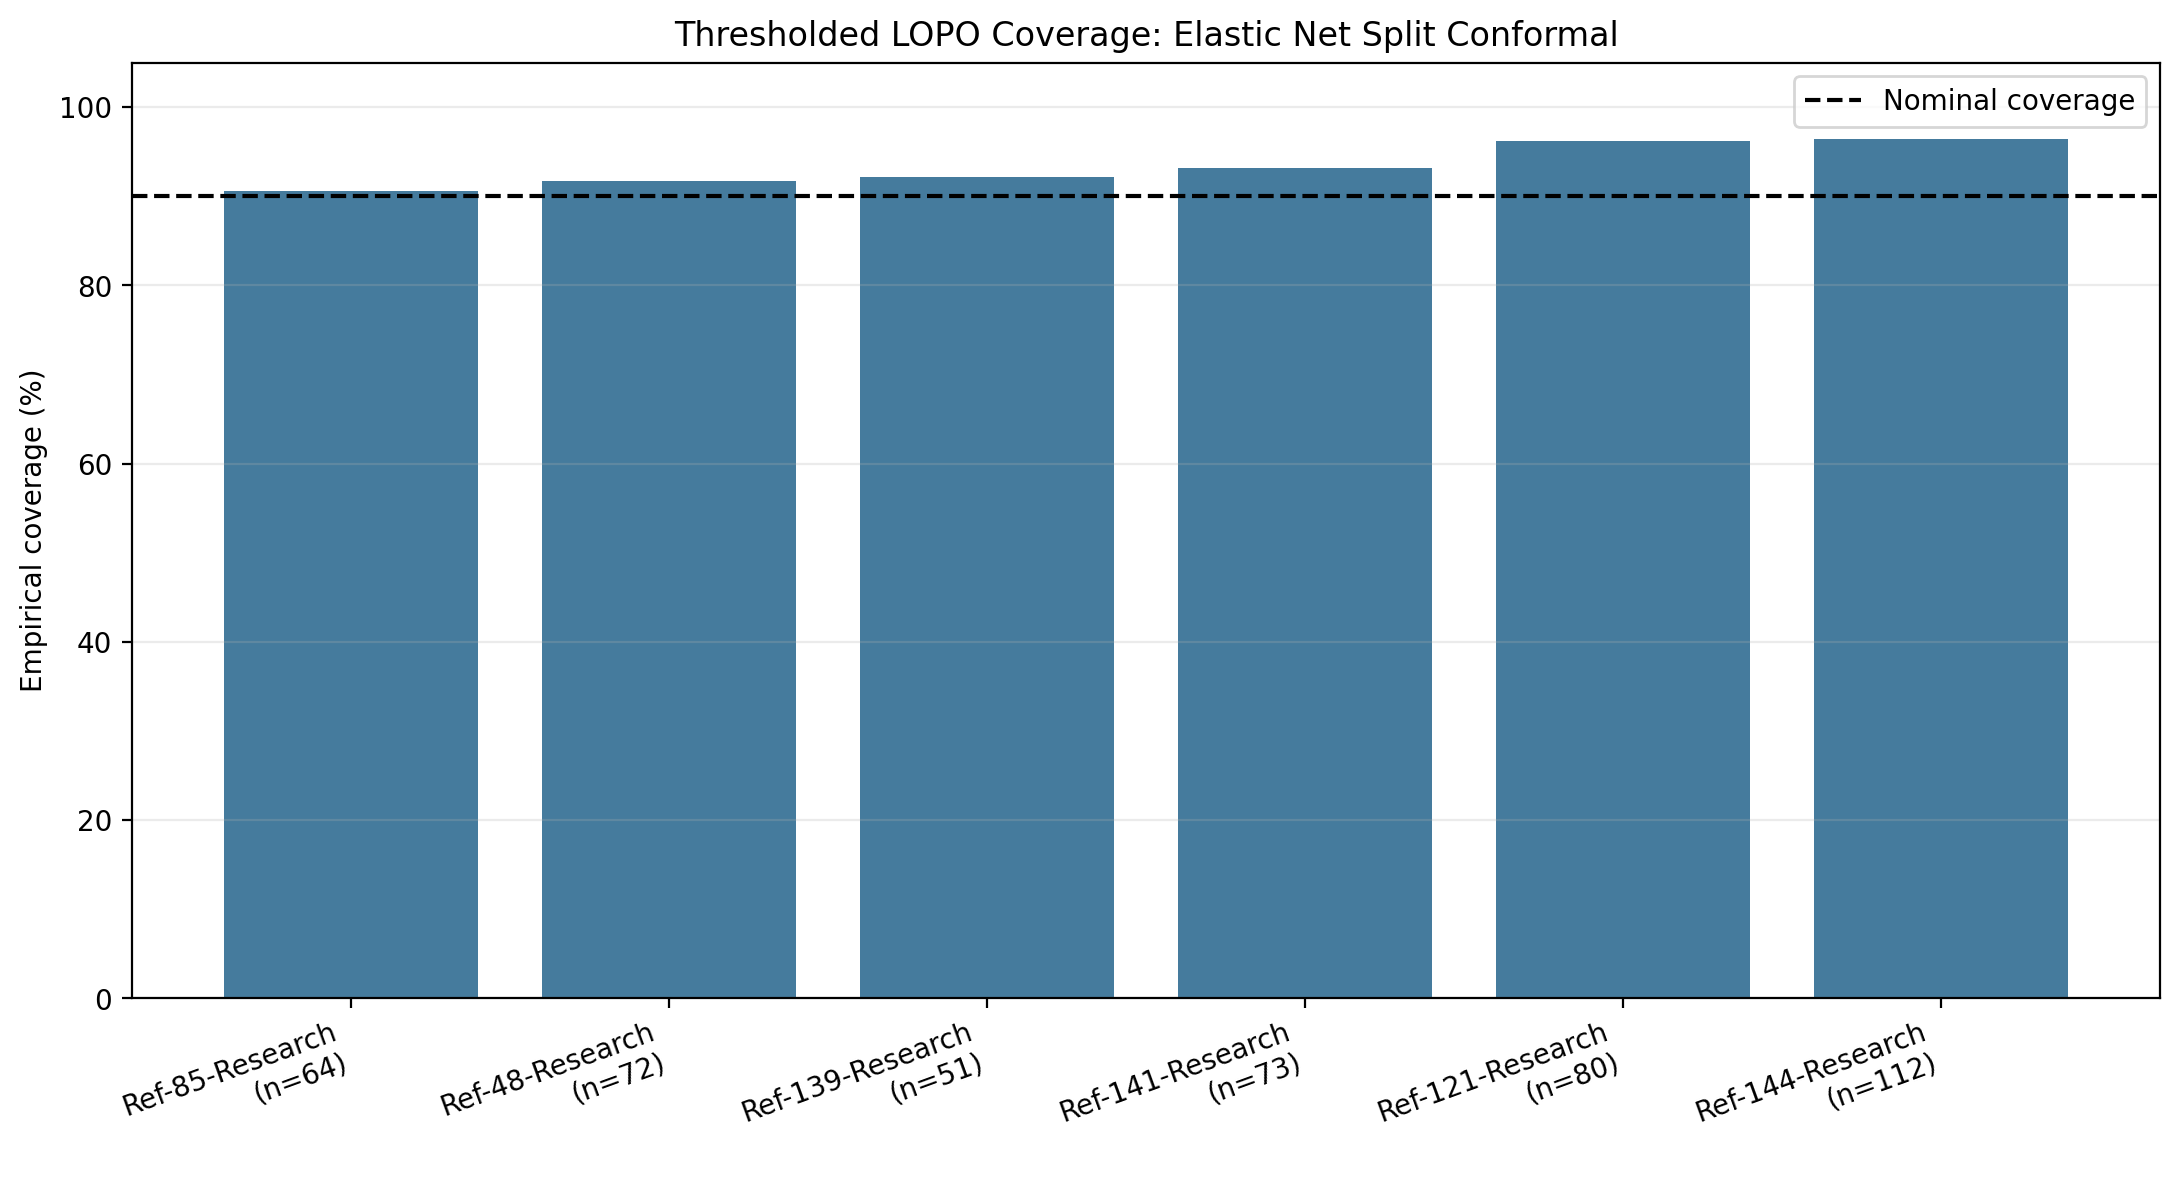

In [9]:
display(lopo_roles)
assert set(lopo_leakage['status']) == {'pass'}
display(lopo_summary[[
    'method', 'aggregation', 'n_publications', 'n_rows',
    'EmpiricalCoverage', 'CoverageGap', 'MeanIntervalWidth',
    'MeanWinklerScore', 'RMSE', 'R2'
]].round(3))
show_figure('week09_lopo_coverage.png', width=1000)

## 9. Which Reliable Publications Remain Difficult?

The LOPO table below shows whether the same uncertainty method stays calibrated publication by publication. This matters because marginal coverage can be good while some publications remain overconfident.

,publication_group,n_rows,EmpiricalCoverage,MeanIntervalWidth,MeanWinklerScore,RMSE,Bias
20,Ref-85-Research,64,0.906,102.343,114.893,31.152,22.508
15,Ref-48-Research,72,0.917,100.731,110.925,30.072,14.194
25,Ref-139-Research,51,0.922,100.137,116.002,26.667,-17.584
10,Ref-141-Research,73,0.932,103.653,113.272,36.324,-35.015
5,Ref-121-Research,80,0.962,104.586,114.659,28.529,-9.913
0,Ref-144-Research,112,0.964,100.134,105.618,24.502,10.196


,method,publication_group,n_rows,EmpiricalCoverage,MeanIntervalWidth,MeanWinklerScore,Week08PointRMSE,Week08PointBias,numeric_out_of_training_range_rate,unseen_category_rate
12,bayesian_ridge_conformalized,Ref-141-Research,73,0.849,98.533,124.017,30.790,-29.082,0.000,0.000
22,bayesian_ridge_conformalized,Ref-85-Research,64,0.906,100.587,114.736,27.833,18.402,0.000,0.000
27,bayesian_ridge_conformalized,Ref-139-Research,51,0.922,99.009,115.517,28.306,-19.862,0.010,0.004
17,bayesian_ridge_conformalized,Ref-48-Research,72,0.958,103.610,109.916,28.107,10.450,0.000,0.093
7,bayesian_ridge_conformalized,Ref-121-Research,80,0.962,107.713,114.938,35.389,-20.133,0.000,0.000
2,bayesian_ridge_conformalized,Ref-144-Research,112,0.964,98.449,104.546,27.225,16.279,0.008,0.000
20,elastic_net_split_conformal,Ref-85-Research,64,0.906,102.343,114.893,27.833,18.402,0.000,0.000
15,elastic_net_split_conformal,Ref-48-Research,72,0.917,100.731,110.925,28.107,10.450,0.000,0.093
25,elastic_net_split_conformal,Ref-139-Research,51,0.922,100.137,116.002,28.306,-19.862,0.010,0.004
10,elastic_net_split_conformal,Ref-141-Research,73,0.932,103.653,113.272,30.790,-29.082,0.000,0.000


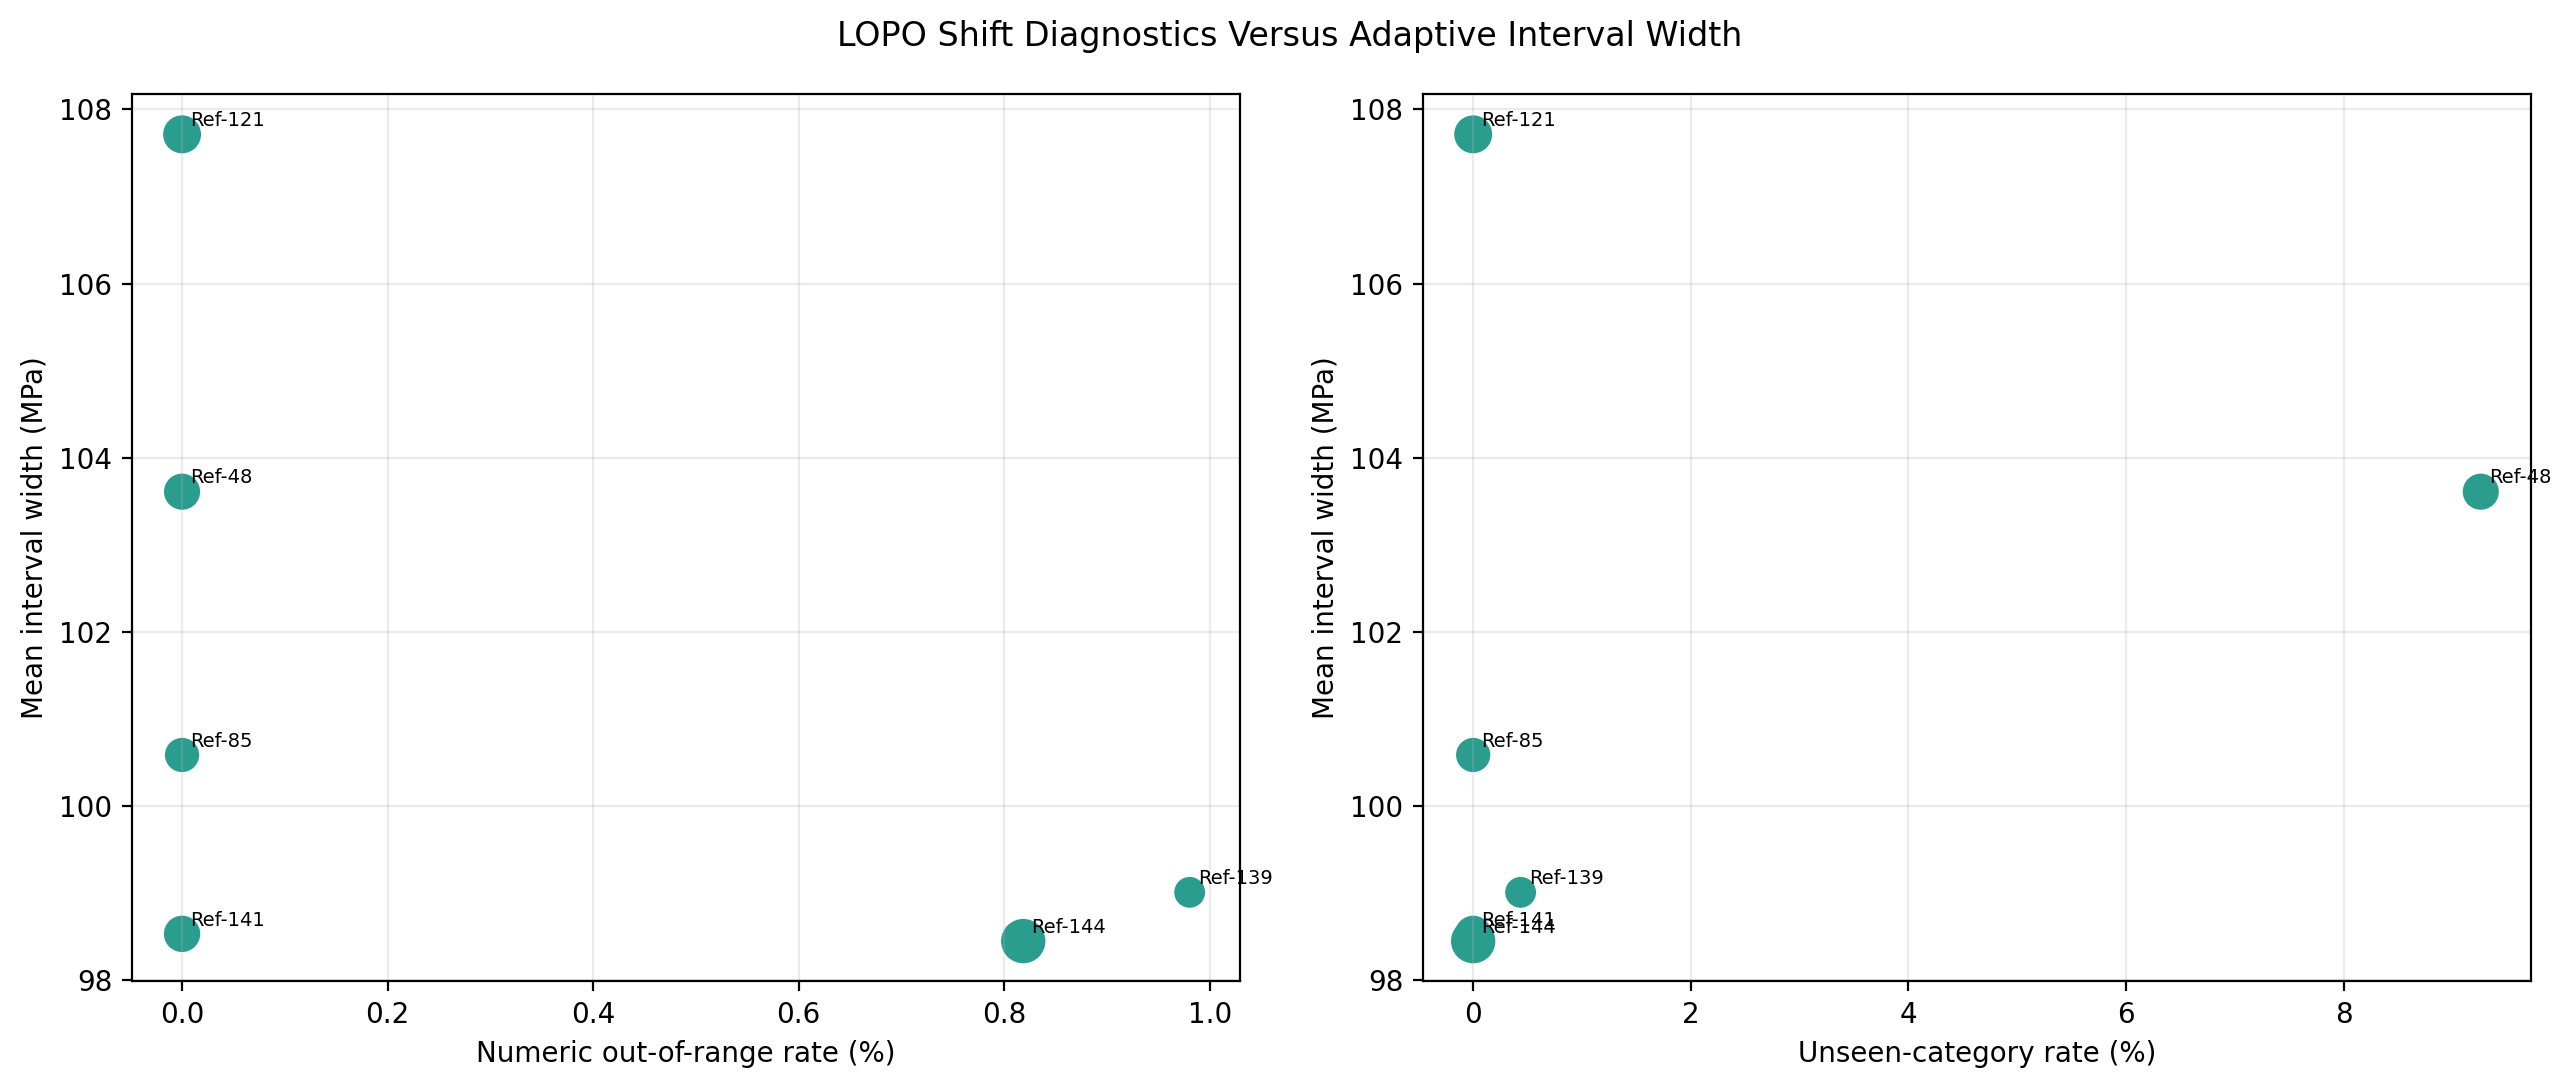

In [10]:
display(lopo_publications.query("method == 'elastic_net_split_conformal'")[[
    'publication_group', 'n_rows', 'EmpiricalCoverage', 'MeanIntervalWidth',
    'MeanWinklerScore', 'RMSE', 'Bias'
]].sort_values('EmpiricalCoverage').round(3))
comparison_columns = [
    'method', 'publication_group', 'n_rows', 'EmpiricalCoverage',
    'MeanIntervalWidth', 'MeanWinklerScore', 'Week08PointRMSE',
    'Week08PointBias', 'numeric_out_of_training_range_rate',
    'unseen_category_rate'
]
display(lopo_comparison.query(
    "method in ['elastic_net_split_conformal', 'bayesian_ridge_conformalized']"
)[comparison_columns].sort_values(['method', 'EmpiricalCoverage']).round(3))
show_figure('week09_lopo_shift_vs_uncertainty.png', width=1050)

## Final Week 9 Conclusions

The corrected Week 9 workflow now uses the refreshed Week 8 shared-dataset outputs. The main lesson is that raw uncertainty estimates are too narrow for publication transfer, while conformal calibration substantially improves reliability. Split conformal is the simplest defendable interval, and conformalized bootstrap is competitive in shared-test Winkler score, but neither removes publication-specific calibration risk completely.

For future improvement, the project needs richer publication/material/testing metadata and possibly group-aware calibration methods, not only narrower interval algorithms.